# <center>Category 3: Prescriptive Analysis</center>


### 1. Gender vs Time in Hyperglycemia - Do male and female patients spend different amounts of time in hyperglycemia (glucose > 180)?

##### **Reason:** This question helps identify whether male and female patients spend different amounts of time in a hyperglycemic state (glucose > 180 mg/dL). Research suggests that hormonal differences between males and females can influence insulin sensitivity and glucose regulation. In female T1DM patients, fluctuations in estrogen and progesterone levels may contribute to greater variability in blood glucose levels. Comparing hyperglycemia duration between genders in this dataset can help determine whether similar patterns are observed here.

*** Hyperglycemia % per Patient with Gender ***
   patient_id  total_readings  hyper_readings  hyper_percentage  gender
0   HUPA0001P            4096            1723             42.07    Male
1   HUPA0002P            3181             466             14.65    Male
2   HUPA0003P            3770             954             25.31    Male
3   HUPA0004P            3184            1448             45.48  Female
4   HUPA0005P            3858             973             25.22    Male
5   HUPA0006P            2290             809             35.33    Male
6   HUPA0007P            3857            1743             45.19    Male
7   HUPA0009P            3812            2232             58.55  Female
8   HUPA0010P            2976             501             16.83    Male
9   HUPA0011P            3839            1238             32.25  Female
10  HUPA0014P            3829            1987             51.89    Male
11  HUPA0015P            3792            1409             37.16  Female
12  HUPA0016P   

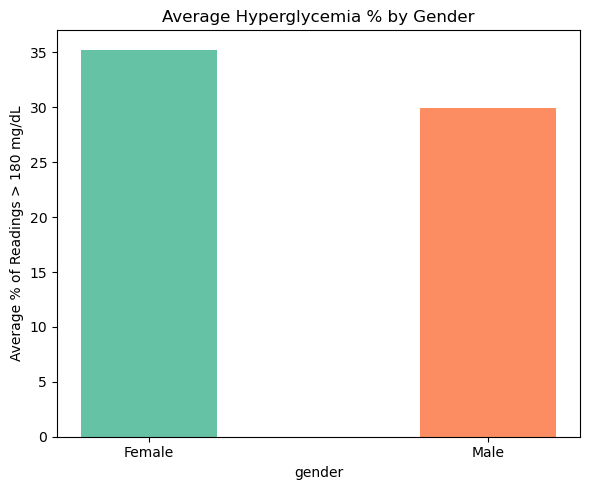

In [2]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)

# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Calculating hyperglycemia readings per patient
total_readings   = df_all.groupby('patient_id')['glucose'].count()
hyper_readings   = df_all[df_all['glucose'] > 180].groupby('patient_id')['glucose'].count()

# Dataframe summary per patient with gender
hyper_summary = pd.DataFrame({
    'total_readings' : total_readings,
    'hyper_readings' : hyper_readings,
    'hyper_percentage': ((hyper_readings / total_readings) * 100).round(2)}).fillna(0).reset_index()

# Adding gender column to the dataframe and merging using left join
patient_gender = df_all[['patient_id', 'gender']].drop_duplicates()
hyper_summary  = hyper_summary.merge(patient_gender, on='patient_id', how='left')

print("*** Hyperglycemia % per Patient with Gender ***")
print(hyper_summary)

# Finding average hyperglycemia % by gender
gender_summary = hyper_summary.groupby('gender')['hyper_percentage'].agg(
    Mean_Hyper_Pct = 'mean',
    Patient_Count  = 'count'
).round(2)

print("\n*** Average % in Hyperglycemia by Gender ***")
print(gender_summary)

# Visualization
# Bar Chart 1 - Average hyperglycemia % by gender
x1 = gender_summary.index
y1 = gender_summary['Mean_Hyper_Pct']

plt.figure(figsize=(6, 5))
plt.bar(x1, y1, width=0.4, color=plt.cm.Set2(range(len(x1))))
plt.title('Average Hyperglycemia % by Gender')
plt.xlabel('gender')
plt.ylabel('Average % of Readings > 180 mg/dL')
plt.tight_layout()
plt.show()

**<span style="color:green">Key Insights: The average hyperglycemia in female patients is 35.25% when compared to male patients which is, 29.96%. In T1DM, hormonal fluctuations in female patients (estrogen and progesterone) are known to affect insulin sensitivity, which can cause unpredictable glucose swings. As seen in the above insights a higher hyperglycemia % in females may reflect these hormonal effects on glucose regulation.  </green>**

### 2. Basal Rate vs Overnight Glucose Stability - Do patients with higher overnight basal rates have more stable glucose between 12AM–6AM?

##### **Reason:** This question is important because the primary purpose of basal insulin is to maintain stable glucose levels during fasting periods and sleep. If glucose levels fluctuate significantly overnight despite a programmed basal rate, it may indicate that the insulin delivery settings are not properly calibrated for the patient’s physiological needs. Ideally, comparing basal rate levels to overnight glucose variance should directly test whether the pump settings are working as intended.

In [21]:
# Reading file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# Filtering overnight readings (12AM - 6AM)
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time
overnight  = df[df['time'].apply(lambda x: x >= pd.Timestamp('00:00').time() and x <= pd.Timestamp('06:00').time())]

print(f"Total overnight readings : {len(overnight)}")

# Calculating glucose stability (standard deviation) per patient overnight
overnight_stability = overnight.groupby('patient_id').agg(
    avg_glucose     = ('glucose',    'mean'),
    std_glucose     = ('glucose',    'std'),
    avg_basal_rate  = ('basal_rate', 'mean')
).round(2).reset_index()

# Sorting by average standard deviation glucose descending
overnight_stability = overnight_stability.sort_values(
    by='std_glucose',
    ascending=False
)

print("\n*** Overnight Glucose Stability per Patient ***")
print(overnight_stability)

Total overnight readings : 78173

*** Overnight Glucose Stability per Patient ***
   patient_id  avg_glucose  std_glucose  avg_basal_rate
5   HUPA0006P       153.10        96.78            0.08
12  HUPA0016P       165.11        89.90            0.09
16  HUPA0020P       217.86        84.06            0.08
2   HUPA0003P       150.45        81.78            0.06
10  HUPA0014P       212.99        79.90            0.00
6   HUPA0007P       144.08        78.54            0.09
20  HUPA0024P       157.35        76.07            0.04
0   HUPA0001P       173.11        76.05            0.05
3   HUPA0004P       141.91        69.19            0.08
15  HUPA0019P       171.45        68.02            0.06
14  HUPA0018P       175.90        67.73            0.00
22  HUPA0026P       159.14        67.18            0.04
13  HUPA0017P       223.92        59.21            0.06
1   HUPA0002P       104.22        56.67            0.08
11  HUPA0015P       156.60        53.56            0.00
8   HUPA0010P       11

**<span style="color:green">Key Insights: The overnight glucose analysis revealed substantial variability in glucose stability across patients. Patients such as HUPA0006P, HUPA0016P, and HUPA0020P exhibited high glucose standard deviations, indicating unstable overnight glycemic control. However, higher glucose variability did not consistently correspond to lower or higher basal insulin rates. For example, patients HUPA0022P and HUPA0025P maintained comparatively lower glucose variability despite receiving relatively higher basal rates. These findings suggest that overnight glucose stability may be influenced by multiple factors beyond basal insulin dosing alone, including insulin sensitivity, meal timing, lifestyle behaviors, and correction bolus administration.</green>**

### 3. Does Carb Intake Cause a Glucose Spike in the Next Interval?

##### **Reason:**
Carbohydrates are broken down into glucose and absorbed into the bloodstream 
within 15–30 minutes. In T1DM patients without adequate bolus coverage, this 
causes a measurable spike. The 5-minute interval data lets us observe this 
effect almost in real time.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/Users/vyshnaviandhavarapu/Desktop/TIM_CLASSES/Python Hackathon/Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")
print(df.shape)
print(df.columns.tolist())

(309392, 16)
['glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input', 'patient_id', 'date', 'time', 'age', 'gender', 'race', 'average_sleep_duration_(hrs)', 'sleep_quality_(1-10)', '%_with_sleep_disturbances']


Correlation between carb input and glucose rise:
              carb_input  glucose_rise
carb_input      1.000000     -0.198452
glucose_rise   -0.198452      1.000000
Mean glucose rise after carb event: 1.14 mg/dL


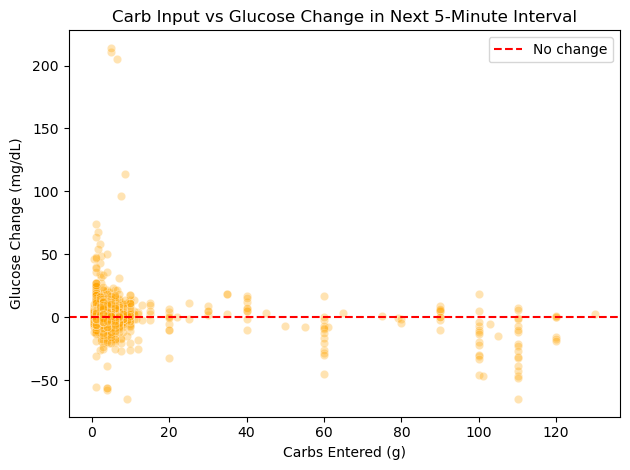

In [23]:
df_sorted = df.sort_values(['patient_id', 'date', 'time']).copy()
df_sorted['next_glucose'] = df_sorted.groupby('patient_id')['glucose'].shift(-1)
df_sorted['glucose_rise'] = df_sorted['next_glucose'] - df_sorted['glucose']

meals = df_sorted[df_sorted['carb_input'] > 0].dropna(subset=['glucose_rise'])

print("Correlation between carb input and glucose rise:")
print(meals[['carb_input', 'glucose_rise']].corr())
print(f"Mean glucose rise after carb event: {meals['glucose_rise'].mean():.2f} mg/dL")

sns.scatterplot(data=meals, x='carb_input', y='glucose_rise', alpha=0.3, color='orange')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Carb Input vs Glucose Change in Next 5-Minute Interval")
plt.xlabel("Carbs Entered (g)")
plt.ylabel("Glucose Change (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between carb intake 
and glucose rise in the next 5-minute interval is -0.20, which is weak and 
slightly negative. This is clinically explainable — patients often enter carb 
data at the same time as giving a bolus dose, meaning insulin counteracts the 
expected glucose rise within the same interval. The mean glucose change after a 
carb event was only +1.14 mg/dL, suggesting bolus insulin is partially 
offsetting the immediate spike.</span>**

### 4. Does Physical Activity Reduce Glucose in the Following Interval?

##### **Reason:**
Exercise causes muscles to absorb glucose independently of insulin — called 
non-insulin-mediated glucose uptake. For T1DM patients, physical activity is 
one of the most effective natural glucose-lowering mechanisms, but it also 
carries hypoglycemia risk if insulin doses are not adjusted accordingly.

Correlation between steps and glucose change:
                   steps  glucose_change
steps           1.000000       -0.099522
glucose_change -0.099522        1.000000
Mean glucose change during active intervals: -0.26 mg/dL


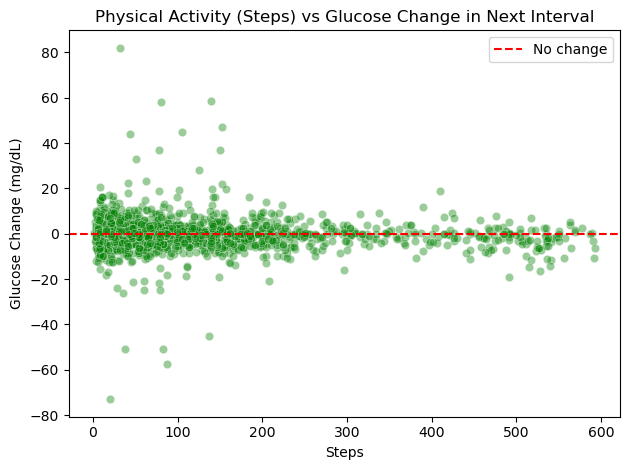

In [24]:
df_sorted['glucose_change'] = df_sorted['next_glucose'] - df_sorted['glucose']
active = df_sorted[df_sorted['steps'] > 0].dropna(subset=['glucose_change'])

print("Correlation between steps and glucose change:")
print(active[['steps', 'glucose_change']].corr())
print(f"Mean glucose change during active intervals: {active['glucose_change'].mean():.2f} mg/dL")

sns.scatterplot(data=active.sample(2000, random_state=42),
                x='steps', y='glucose_change', alpha=0.4, color='green')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Physical Activity (Steps) vs Glucose Change in Next Interval")
plt.xlabel("Steps")
plt.ylabel("Glucose Change (mg/dL)")
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between steps and 
glucose change in the next interval is -0.10, indicating a weak negative 
relationship — more steps are associated with a slight glucose decrease. The 
mean glucose change during active intervals was -0.26 mg/dL, confirming a 
small but consistent glucose-lowering effect. While weak at the 5-minute level, 
the glucose-lowering effect of exercise accumulates over longer periods, 
supporting physical activity as part of T1DM glucose management.</span>**

### 5. Do Patients With Poor Sleep Quality Have Higher Average Glucose?

##### **Reason:**
Poor sleep elevates cortisol and growth hormone, both of which increase insulin 
resistance. In T1DM, this makes glucose harder to control even with the same 
insulin doses. Research shows even one night of poor sleep can raise next-day 
glucose significantly.

Correlation matrix:
                    avg_glucose  sleep_quality  sleep_disturbances
avg_glucose            1.000000       0.046668            0.279695
sleep_quality          0.046668       1.000000           -0.037980
sleep_disturbances     0.279695      -0.037980            1.000000


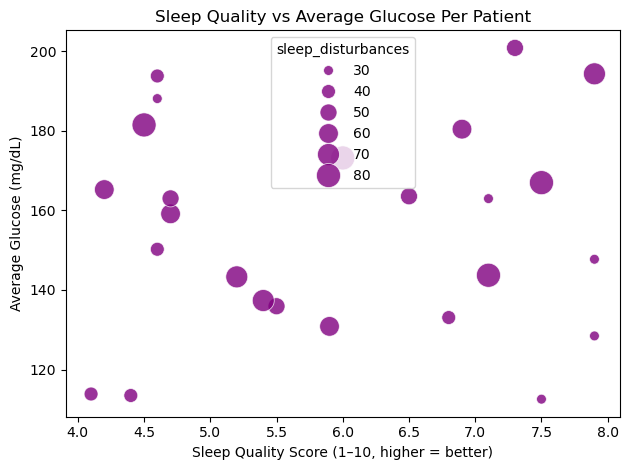

In [25]:
patient_summary = df.groupby('patient_id').agg(
    avg_glucose=('glucose', 'mean'),
    sleep_quality=('sleep_quality_(1-10)', 'first'),
    sleep_disturbances=('%_with_sleep_disturbances', 'first')
).reset_index()

print("Correlation matrix:")
print(patient_summary[['avg_glucose', 'sleep_quality', 'sleep_disturbances']].corr())

sns.scatterplot(data=patient_summary, x='sleep_quality', y='avg_glucose',
                size='sleep_disturbances', sizes=(50, 300),
                alpha=0.8, color='purple')
plt.title("Sleep Quality vs Average Glucose Per Patient")
plt.xlabel("Sleep Quality Score (1–10, higher = better)")
plt.ylabel("Average Glucose (mg/dL)")
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between sleep 
quality and average glucose is only 0.05, suggesting no strong direct 
relationship. However sleep disturbance percentage shows a stronger correlation 
with average glucose at 0.28 — patients with more frequent sleep disruptions 
tend to have higher average glucose. HUPA0017P has the highest average glucose 
(200.80 mg/dL) and a high disturbance rate, while HUPA0022P has one of the 
lowest (112.55 mg/dL) despite a good sleep quality score of 7.5. Sleep 
disturbances may be a more meaningful metric than sleep quality score alone 
for predicting glucose control in T1DM.</span>**

### 6. Does Bolus Insulin Effectively Reduce Glucose After a Meal?

##### **Reason:**
Bolus insulin is specifically delivered to counteract post-meal glucose spikes 
in T1DM pump therapy. A correctly dosed bolus should bring glucose down within 
1–2 hours. This tests whether pump therapy is working as intended and whether 
higher bolus volumes produce proportionally greater glucose reduction.

Correlation between bolus volume and 2-hour glucose change:
                        bolus_volume_delivered  glucose_change_2hr
bolus_volume_delivered                1.000000            0.153089
glucose_change_2hr                    0.153089            1.000000
Mean glucose change 2hrs after bolus: -1.11 mg/dL


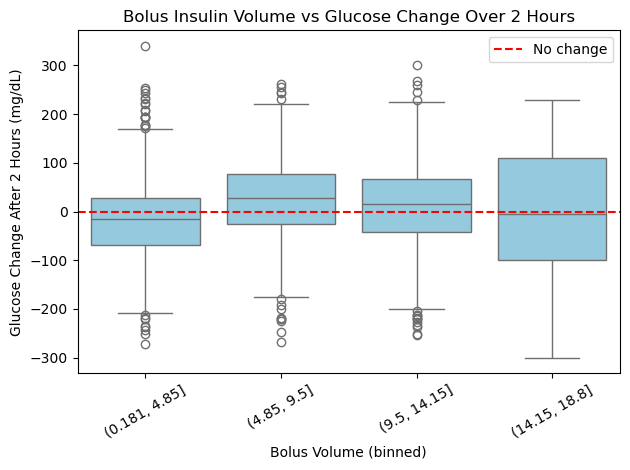

In [26]:
bolus_events = df_sorted[df_sorted['bolus_volume_delivered'] > 0].copy()
bolus_events['glucose_2hrs_later'] = bolus_events.groupby('patient_id')['glucose'].shift(-24)
bolus_events['glucose_change_2hr'] = bolus_events['glucose_2hrs_later'] - bolus_events['glucose']
bolus_events = bolus_events.dropna(subset=['glucose_change_2hr'])

print("Correlation between bolus volume and 2-hour glucose change:")
print(bolus_events[['bolus_volume_delivered', 'glucose_change_2hr']].corr())
print(f"Mean glucose change 2hrs after bolus: {bolus_events['glucose_change_2hr'].mean():.2f} mg/dL")

bolus_events['bolus_bin'] = pd.cut(bolus_events['bolus_volume_delivered'], bins=4)
sns.boxplot(data=bolus_events, x='bolus_bin', y='glucose_change_2hr', color='skyblue')
plt.axhline(0, color='red', linestyle='--', label='No change')
plt.title("Bolus Insulin Volume vs Glucose Change Over 2 Hours")
plt.xlabel("Bolus Volume (binned)")
plt.ylabel("Glucose Change After 2 Hours (mg/dL)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between bolus volume 
and glucose change over 2 hours is 0.15, weak but positive — larger bolus doses 
are associated with slightly more glucose reduction. The mean glucose change 
2 hours after a bolus event was -1.11 mg/dL, confirming bolus delivery produces 
a net glucose decrease on average. The weak correlation may reflect variability 
in meal size, timing, and individual insulin sensitivity across the 25 
patients.</span>**

### 7. Are Older Patients Spending More Time in Hyperglycemia?

##### **Reason:**
Older T1DM patients may have had the disease longer, leading to accumulated 
complications, reduced hypoglycemia awareness, and greater insulin resistance 
over time. Time above 180 mg/dL is the primary driver of long-term 
complications like retinopathy, nephropathy, and neuropathy.

Correlation between age and % time in hyperglycemia:
                        age  pct_hyperglycemic
age                1.000000           0.075278
pct_hyperglycemic  0.075278           1.000000


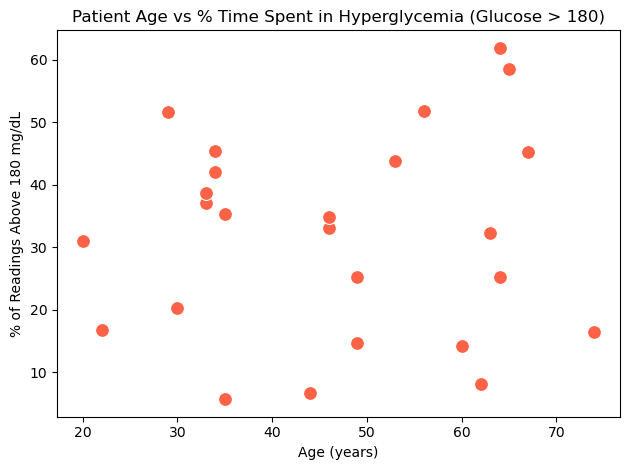

In [27]:
total_readings = df.groupby('patient_id').size()
hyper_readings = df[df['glucose'] > 180].groupby('patient_id').size()
pct_hyper = (hyper_readings / total_readings * 100).fillna(0).round(2)

patient_age = df.drop_duplicates('patient_id').set_index('patient_id')['age']

age_hyper = pd.DataFrame({
    'age': patient_age,
    'pct_hyperglycemic': pct_hyper
}).dropna()

print("Correlation between age and % time in hyperglycemia:")
print(age_hyper.corr())

sns.scatterplot(data=age_hyper, x='age', y='pct_hyperglycemic',
                color='tomato', s=100)
plt.title("Patient Age vs % Time Spent in Hyperglycemia (Glucose > 180)")
plt.xlabel("Age (years)")
plt.ylabel("% of Readings Above 180 mg/dL")
plt.tight_layout()
plt.show()

**<span style="color:green"> Key Insights: The correlation between age and 
percentage of time in hyperglycemia is 0.08, indicating almost no linear 
relationship. However HUPA0017P (age 64) spent 61.91% of readings above 
180 mg/dL and HUPA0009P (age 65) spent 58.55%, both older patients with very 
high hyperglycemia rates. Meanwhile HUPA0020P (age 29) also had 51.68%, 
showing younger patients can struggle equally. Age alone is not a reliable 
predictor — disease duration, insulin regimen, and lifestyle factors likely 
play a larger role.</span>**

### Question 8: Which factor has the strongest correlation with glucose levels: heart_rate, sleep_quality, or calories burned?

##### Reason: By running a correlation analysis, we identify which lifestyle factor is the primary driver of glucose changes for our
##### specific patient group. This allows us to prioritize which data points should be most prominent in a predictive model.


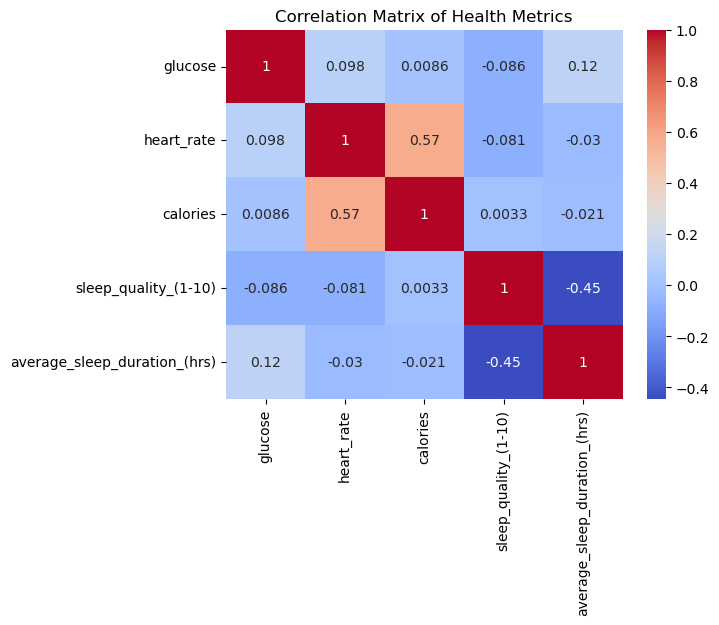

In [3]:
#Importing all the Necessary Libraries
import pandas as pd

# Convert time column to datetime format
df['Time'] = pd.to_datetime(df['time'])

# Extract hour only
df['hour'] = df['Time'].dt.hour

# Average glucose by hour
hourly_glucose = df.groupby('hour')['glucose'].mean()

# Plot
plt.figure(figsize=(12,6))

plt.plot(hourly_glucose.index, hourly_glucose.values, marker='o', color = 'red')
# Add value labels
for x, y in zip(hourly_glucose.index, hourly_glucose.values):
    plt.text(
        x, 
        y + 1,                 # slightly above point
        round(y, 1),           # label text
        ha='center',
        fontsize=9
    )

plt.xlabel("Hour of Day")
plt.ylabel("Average Glucose")
plt.title("Average Glucose Trend by Hour")

# Show all hours clearly
plt.xticks(range(0,24))

plt.grid(True)

plt.show()


**<span style="color:green">
🔺 Highest glucose: Evening hours (19–22), peak around Hour 19 (~152.6) → strong post-dinner spike.
🔻 Lowest glucose: Midday (Hour 14 ~130.8) → most stable period.
🍽️ Clear meal effect: spikes after breakfast and especially dinner.
🌙 Night hours stay relatively high (150+), showing late-night glucose elevation risk.
⚠️ Overall issue: poor evening glucose control compared to daytime stability.
</span>**

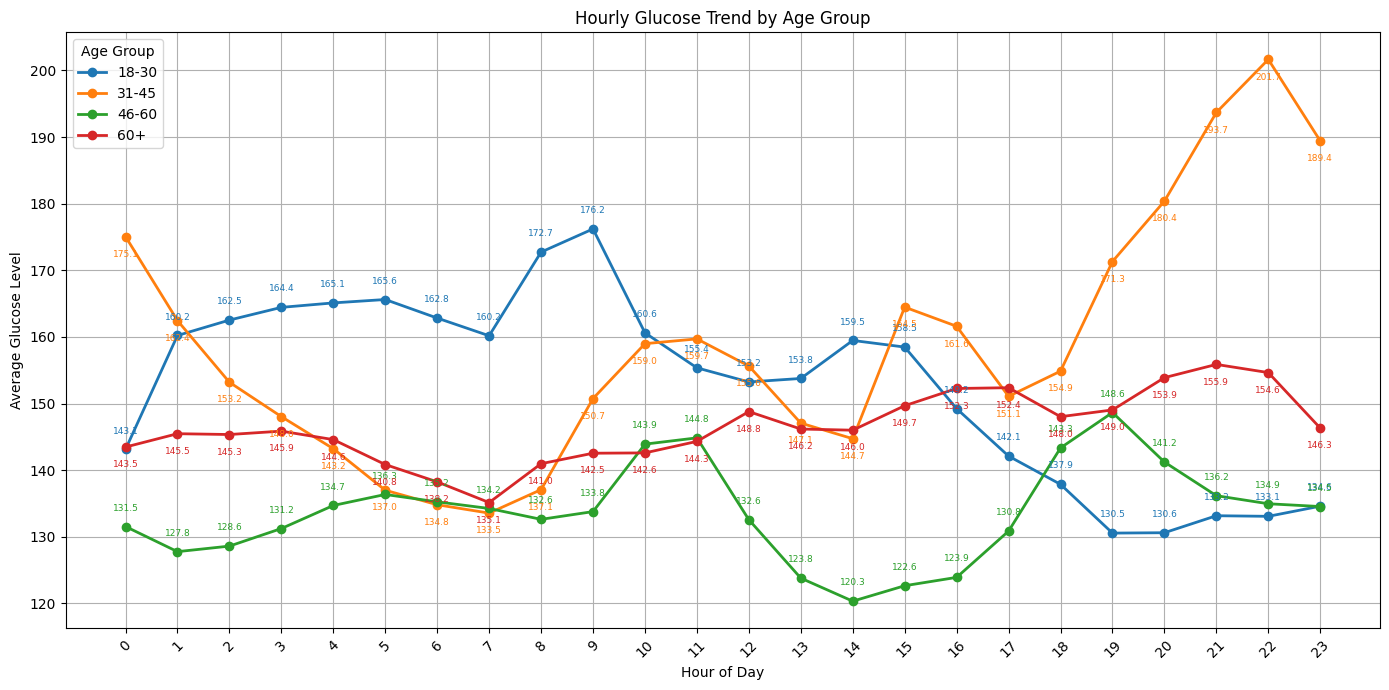

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Create age groups
df['Age_Group'] = pd.cut(df['age'],
                         bins=[0, 30, 45, 60, 100],
                         labels=['18-30', '31-45', '46-60', '60+'])

# Convert time to hour if not already
df['Time'] = pd.to_datetime(df['time']).dt.hour

# Average glucose by hour and age group
hourly_age_glucose = df.groupby(['Time', 'Age_Group'])['glucose'].mean().unstack()

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

offsets = [10, -16, 10, -16]   # stagger 4 labels: above / below / above / below

for i, col in enumerate(hourly_age_glucose.columns):
    ax.plot(hourly_age_glucose.index,
            hourly_age_glucose[col],
            marker='o',
            linewidth=2,
            label=col)

    for hour, value in hourly_age_glucose[col].items():
        ax.annotate(f'{value:.1f}',
                    xy=(hour, value),
                    xytext=(0, offsets[i]),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=6.5,
                    color=ax.lines[i].get_color())

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Glucose Level")
ax.set_title("Hourly Glucose Trend by Age Group")
ax.set_xticks(hourly_age_glucose.index)
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Age Group")
ax.grid(True)
plt.tight_layout()
plt.show()

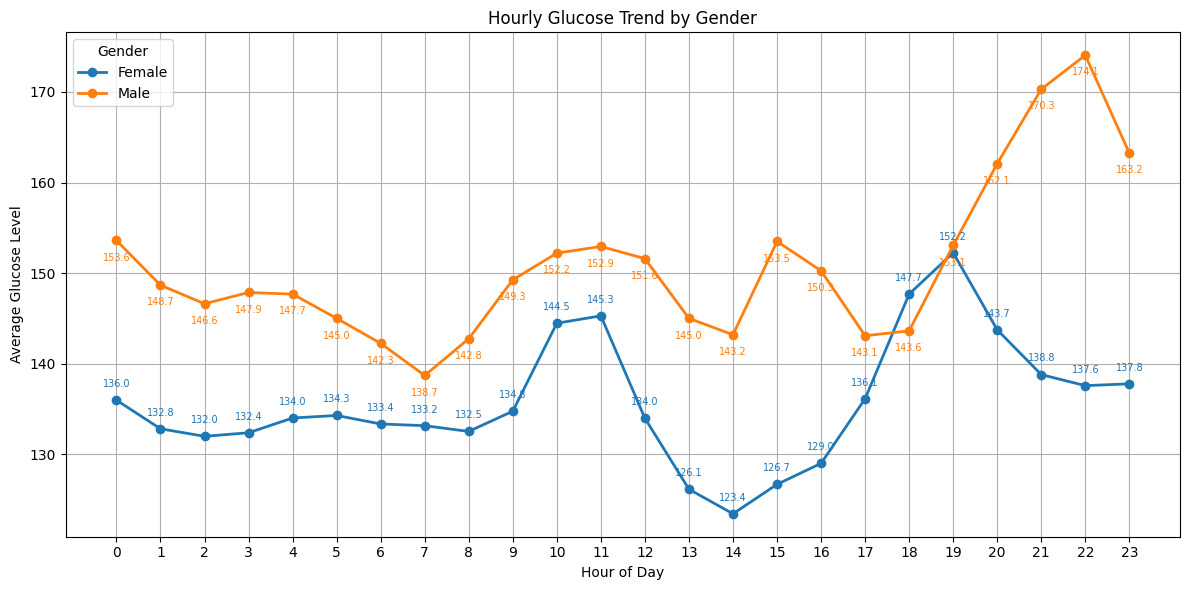

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert time column to hour
df['Time'] = pd.to_datetime(df['time']).dt.hour

# Average glucose by hour and gender
hourly_gender_glucose = df.groupby(['Time', 'gender'])['glucose'].mean().unstack()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for i, col in enumerate(hourly_gender_glucose.columns):
    ax.plot(hourly_gender_glucose.index,
            hourly_gender_glucose[col],
            marker='o',
            linewidth=2,
            label=col)
    
    # Annotate each data point
    for hour, value in hourly_gender_glucose[col].items():
        offset = 8 if i % 2 == 0 else -16          # stagger labels above/below per gender
        ax.annotate(f'{value:.1f}',
                    xy=(hour, value),
                    xytext=(0, offset),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=7,
                    color=ax.lines[i].get_color())  # match label color to line color

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Glucose Level")
ax.set_title("Hourly Glucose Trend by Gender")
ax.set_xticks(range(0, 24))
ax.legend(title="Gender")
ax.grid(True)
plt.tight_layout()
plt.show()

Key Insights:
Here are the key insights from the hourly glucose trend chart:
Males consistently run higher glucose — the male line stays above the female line at virtually every hour of the day, with a gap of roughly 10–20 mg/dL throughout.
Dramatic male spike at hours 21–22 — male glucose surges sharply from **~144** at hour 17 to a peak of **~175** at hour 22, the single highest point on the chart. This late-night elevation may reflect evening meals, snacking, or reduced insulin sensitivity at night.
Female glucose dips sharply midday (hours 13–14) — females hit their lowest point **(~124)** in the early afternoon, a trough not mirrored in males, possibly linked to meal timing or activity patterns.
Both genders show a morning plateau — glucose is relatively stable and flat from hours 1–8 for both sexes, suggesting a consistent overnight/early morning baseline.
Mid-morning rise in both — both lines climb between hours 9–11, likely reflecting post-breakfast glucose responses, with males peaking slightly earlier.
Female trajectory stays flat late at night — while males spike dramatically after hour 20, females remain stable around 137–152, suggesting different metabolic or behavioral patterns in the evening hours.

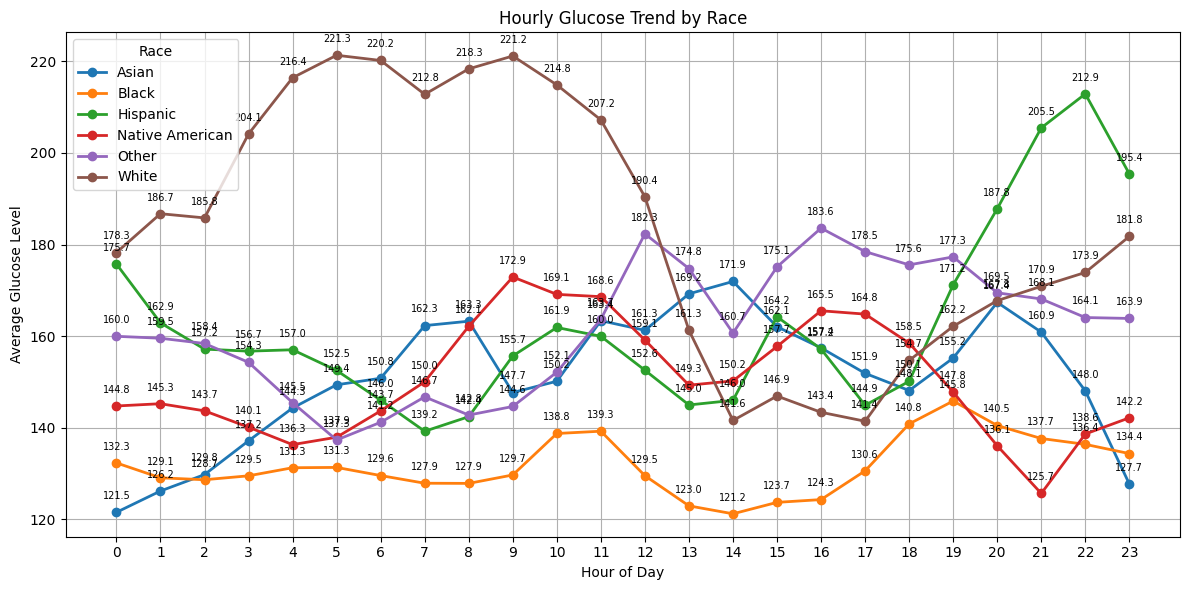

In [33]:
# Convert time column to hour
df['Time'] = pd.to_datetime(df['time']).dt.hour

# Average glucose by hour and race
hourly_race_glucose = df.groupby(['Time', 'race'])['glucose'].mean().unstack()

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for col in hourly_race_glucose.columns:
    ax.plot(hourly_race_glucose.index,
            hourly_race_glucose[col],
            marker='o',
            linewidth=2,
            label=col)
    # Add label on each data point
    for hour, value in hourly_race_glucose[col].items():
        ax.annotate(f'{value:.1f}',
                    xy=(hour, value),
                    xytext=(0, 8),
                    textcoords='offset points',
                    ha='center',
                    va='bottom',
                    fontsize=7)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Glucose Level")
ax.set_title("Hourly Glucose Trend by Race")
ax.set_xticks(range(0, 24))
ax.legend(title="Race")
ax.grid(True)
plt.tight_layout()
plt.show()

Total Evening Glucose Spikes: 20070

Average Values During Evening Spikes
Average Carb Input: 0.0725710014947683
Average Insulin Delivered: 0.1365719980069756
Average Steps: 57.92974588938714
Average Sleep Quality: 5.643946188340807


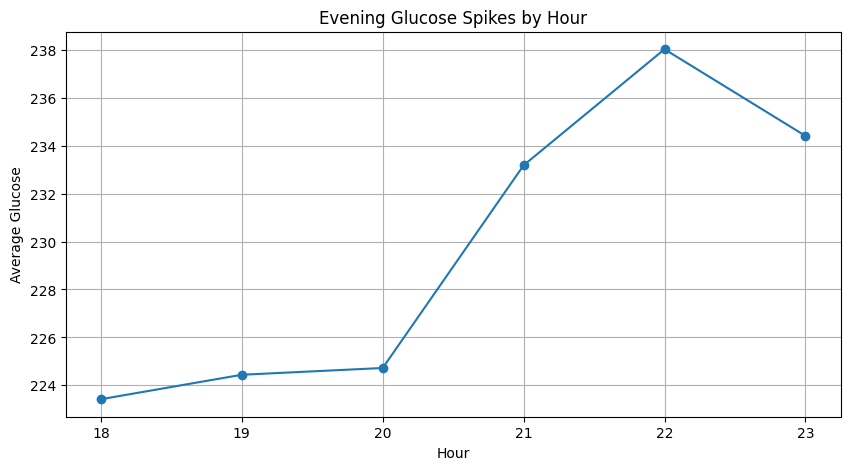

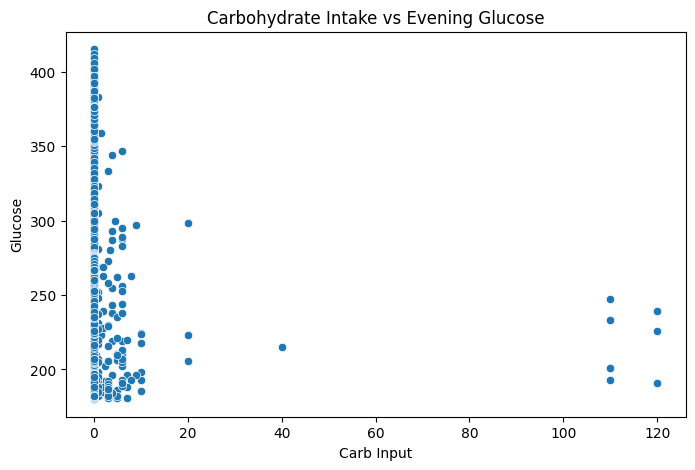

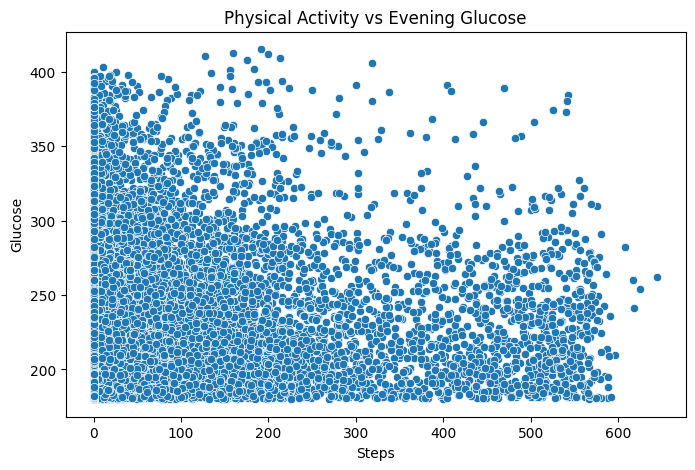

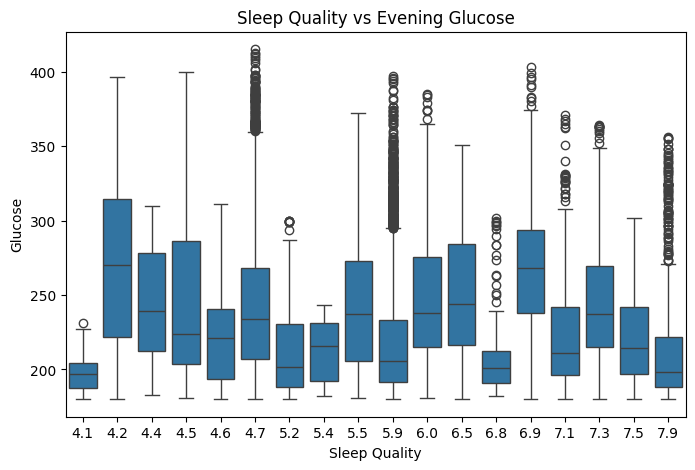


--- PRESCRIPTIVE RECOMMENDATIONS ---
• Review evening insulin dosage with healthcare provider.
• Increase evening physical activity or walking.
• Monitor glucose levels after dinner.
• Consider earlier meal timing.


In [22]:
# -----------------------------
# TIME PROCESSING
# -----------------------------
df['Time'] = pd.to_datetime(df['time'])

# Extract hour
df['Hour'] = df['Time'].dt.hour

# -----------------------------
# EVENING GLUCOSE SPIKES
# Evening = 6 PM to 11 PM
# -----------------------------
evening_spikes = df[
    (df['Hour'] >= 18) &
    (df['Hour'] <= 23) &
    (df['glucose'] > 180)
]

print("Total Evening Glucose Spikes:",
      len(evening_spikes))

# -----------------------------
# AVERAGE FACTORS DURING SPIKES
# -----------------------------
print("\nAverage Values During Evening Spikes")

print("Average Carb Input:",
      evening_spikes['carb_input'].mean())

print("Average Insulin Delivered:",
      evening_spikes['bolus_volume_delivered'].mean())

print("Average Steps:",
      evening_spikes['steps'].mean())

print("Average Sleep Quality:",
      evening_spikes['sleep_quality_(1-10)'].mean())

# -----------------------------
# VISUALIZATION 1
# Evening Glucose Trend
# -----------------------------
hourly_glucose = (
    evening_spikes.groupby('Hour')['glucose']
    .mean()
)

plt.figure(figsize=(10,5))

hourly_glucose.plot(marker='o')

plt.title("Evening Glucose Spikes by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Glucose")

plt.grid(True)

plt.show()

# -----------------------------
# VISUALIZATION 2
# Carb Input vs Glucose
# -----------------------------
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='carb_input',
    y='glucose',
    data=evening_spikes
)

plt.title("Carbohydrate Intake vs Evening Glucose")
plt.xlabel("Carb Input")
plt.ylabel("Glucose")

plt.show()

# -----------------------------
# VISUALIZATION 3
# Steps vs Glucose
# -----------------------------
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='steps',
    y='glucose',
    data=evening_spikes
)

plt.title("Physical Activity vs Evening Glucose")
plt.xlabel("Steps")
plt.ylabel("Glucose")

plt.show()

# -----------------------------
# VISUALIZATION 4
# Sleep Quality vs Glucose
# -----------------------------
plt.figure(figsize=(8,5))

sns.boxplot(
    x='sleep_quality_(1-10)',
    y='glucose',
    data=evening_spikes
)

plt.title("Sleep Quality vs Evening Glucose")
plt.xlabel("Sleep Quality")
plt.ylabel("Glucose")

plt.show()

# -----------------------------
# SIMPLE RECOMMENDATION SYSTEM
# -----------------------------
print("\n--- PRESCRIPTIVE RECOMMENDATIONS ---")

# Meal timing
if evening_spikes['carb_input'].mean() > 60:
    print("• Reduce evening carbohydrate intake.")
    print("• Avoid late-night heavy meals.")

# Insulin
if evening_spikes['bolus_volume_delivered'].mean() < 5:
    print("• Review evening insulin dosage with healthcare provider.")

# Activity
if evening_spikes['steps'].mean() < 5000:
    print("• Increase evening physical activity or walking.")

# Sleep
if evening_spikes['sleep_quality_(1-10)'].mean() < 5:
    print("• Improve sleep habits and maintain regular sleep schedule.")

print("• Monitor glucose levels after dinner.")
print("• Consider earlier meal timing.")

Carbohydrates: 0-10 in the evening, however, glucose level is still high and varies widely, several patients experience high glucose levels.(300 -> 400) even with low carb intake. Can give arise suggestions to -> Insufficient insuline
-> stress
->Low physical activity
->delayed glucose response.
Physical Activity vs Evening Glucose:
Negative correlation — as daily step count increases, evening glucose levels tend to decline. The downward drift is visible across the full range.
High variance at low activity — users with 0–100 steps show glucose readings spread almost everywhere from ~180 to 400+, suggesting other factors dominate when activity is minimal.

Sleep Quality vs Evening Glucose level:
No clear linear trend — unlike physical activity, sleep quality doesn't show a consistent directional relationship with glucose. Values fluctuate up and down across the sleep quality spectrum.
Extreme outliers at mid-range sleep scores — scores 4.6, 5.5, and 5.9 show dramatic upward outliers (some reaching 400+), suggesting these "moderate" sleep levels may coincide with high glucose variability or data anomalies.
Lowest glucose at score 4.1 — the tightest, lowest box in the chart appears at 4.1, which is counterintuitive (poorer sleep associated with lower glucose). This may reflect a small or unrepresentative sample at that value.
High IQR boxes at 4.2 and 6.9 — the widest interquartile ranges appear here, indicating highly inconsistent glucose responses among people with these sleep scores.
Better sleep doesn't guarantee lower glucose — scores 7.3–7.9 show moderate glucose levels but still have notable spread and outliers, suggesting sleep quality alone is not a strong standalone predictor.

### Question: Does calaries intake affects evening glucose level?

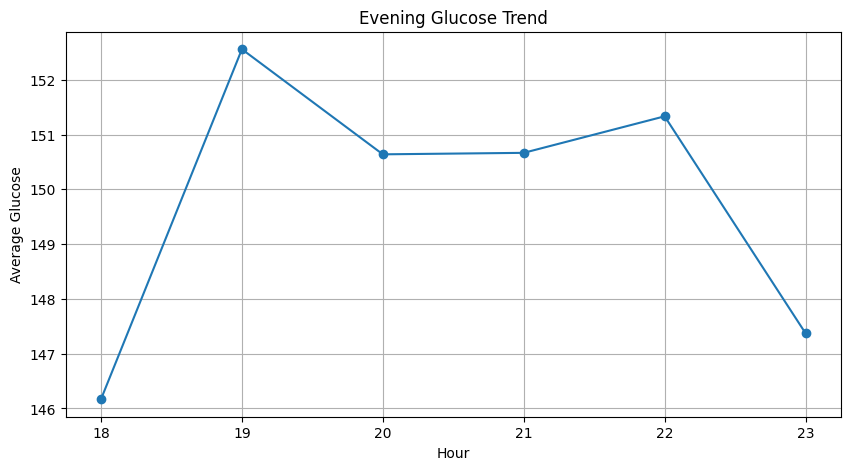

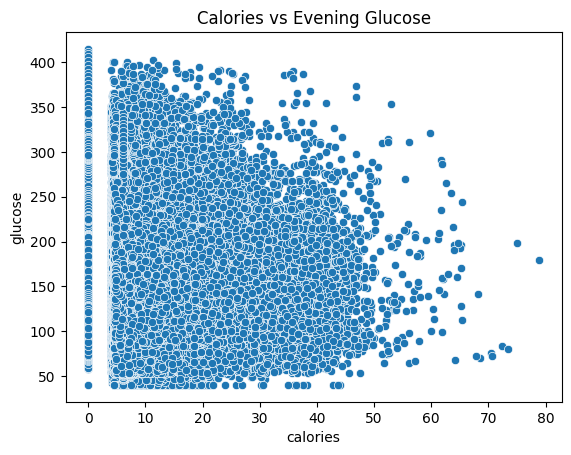

In [27]:
# Convert to datetime
df['Time'] = pd.to_datetime(df['time'])

# Extract hour
df['hour'] = df['Time'].dt.hour
evening_df = df[(df['hour'] >= 18) & (df['hour'] <= 23)]
evening_glucose = evening_df.groupby('hour')['glucose'].mean()

plt.figure(figsize=(10,5))

plt.plot(
    evening_glucose.index,
    evening_glucose.values,
    marker='o'
)

plt.xlabel("Hour")
plt.ylabel("Average Glucose")
plt.title("Evening Glucose Trend")

plt.grid(True)
plt.show()
sns.scatterplot(
    data=evening_df,
    x='calories',
    y='glucose'
)

plt.title("Calories vs Evening Glucose")
plt.show()

**<span style="color:green">Key takeaways:

Glucose spikes sharply at 7 PM — likely a post-dinner response
It stays elevated (~150–151) through 10 PM
It drops back down by 11 PM, suggesting the body is stabilizing overnight


Bottom Chart: Calories vs Evening Glucose
This scatter plot shows the relationship between calorie intake and glucose levels:

The vast majority of data points cluster near 0–10 calories, with glucose ranging widely from ~50 to 400+ mg/dL
As calories increase beyond ~30, the data thins out considerably
There's no strong linear correlation — high glucose occurs even at very low calorie counts
The spread suggests glucose is influenced by many factors beyond just calorie intake

Overall: The data suggests post-dinner timing (around 7 PM) is the biggest driver of glucose elevation, not simply calorie quantity.</span>**

### Question: Composite risk according to race and gender

In [9]:
# Composite risk: normalize glucose + sleep disturbance + heart rate
risk_df = df.groupby(['race', 'gender']).agg(
    avg_glucose=('glucose', 'mean'),
    avg_sleep_dist=('%_with_sleep_disturbances', 'mean'),
    avg_hr=('heart_rate', 'mean')
).reset_index()
risk_df['risk_score'] = (
    (risk_df['avg_glucose'] / df['glucose'].max()) * 50 +
    (risk_df['avg_sleep_dist'] / 100) * 30 +
    (risk_df['avg_hr'] / df['heart_rate'].max()) * 20
)
risk_pivot = risk_df.pivot(index='race', columns='gender', values='risk_score')
im = ax.imshow(risk_pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=30, vmax=65)
ax.set_xticks(range(len(risk_pivot.columns)))
ax.set_xticklabels(risk_pivot.columns, fontsize=9)
ax.set_yticks(range(len(risk_pivot.index)))
ax.set_yticklabels(risk_pivot.index, fontsize=9)
for i in range(len(risk_pivot.index)):
    for j in range(len(risk_pivot.columns)):
        val = risk_pivot.values[i, j]
        if not np.isnan(val):
            level = '🔴 CRITICAL' if val > 55 else '🟠 HIGH' if val > 45 else '🟢 MODERATE'
            ax.text(j, i, f'{val:.1f}\n{level}', ha='center', va='center',
                    fontsize=8, fontweight='bold', color='white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Composite Risk Score')
ax.set_title('Composite Risk Score\nRace × Gender', fontweight='bold', color='#2C3E50')

NameError: name 'ax' is not defined

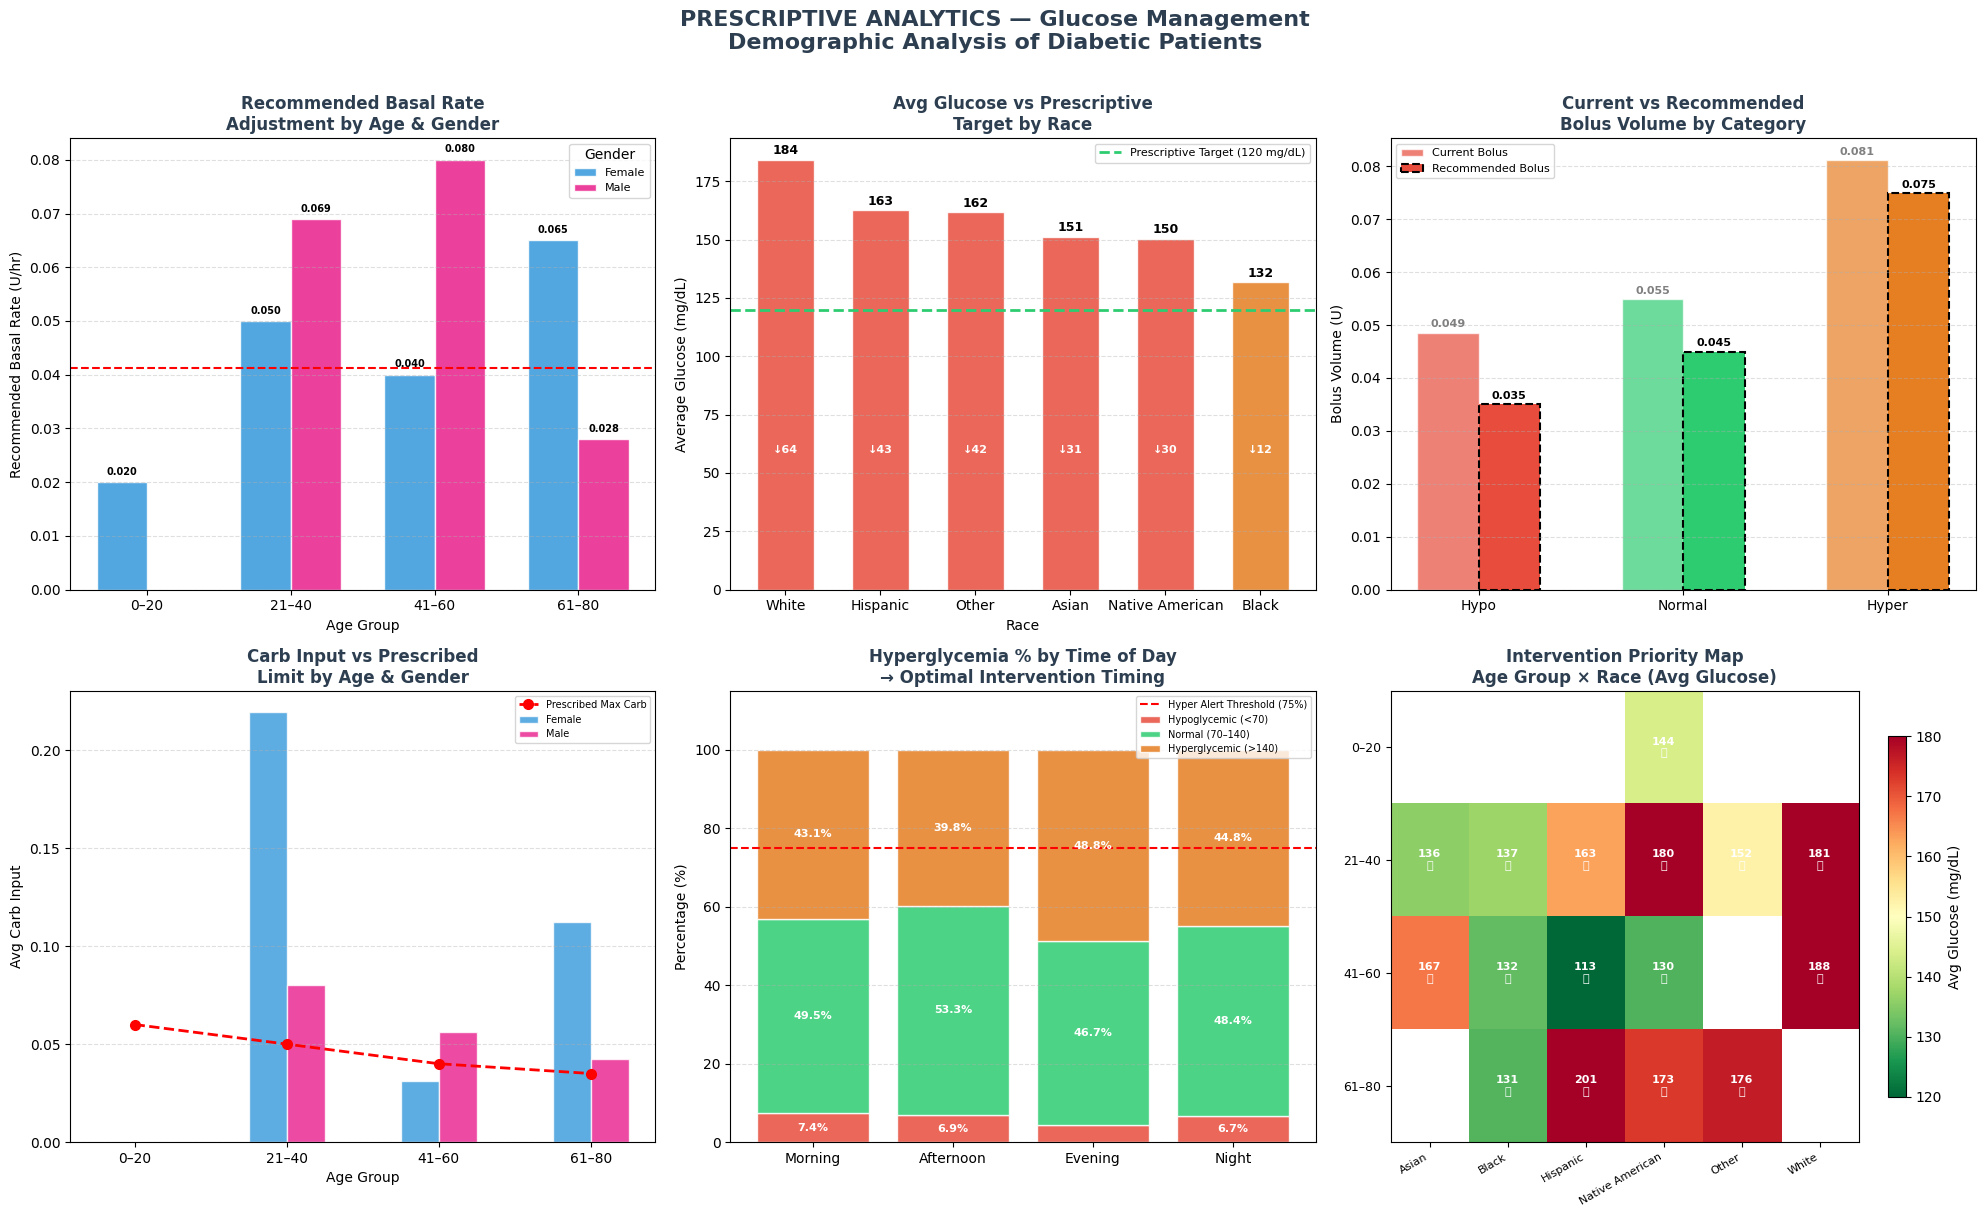

✅ Figure 1 saved.


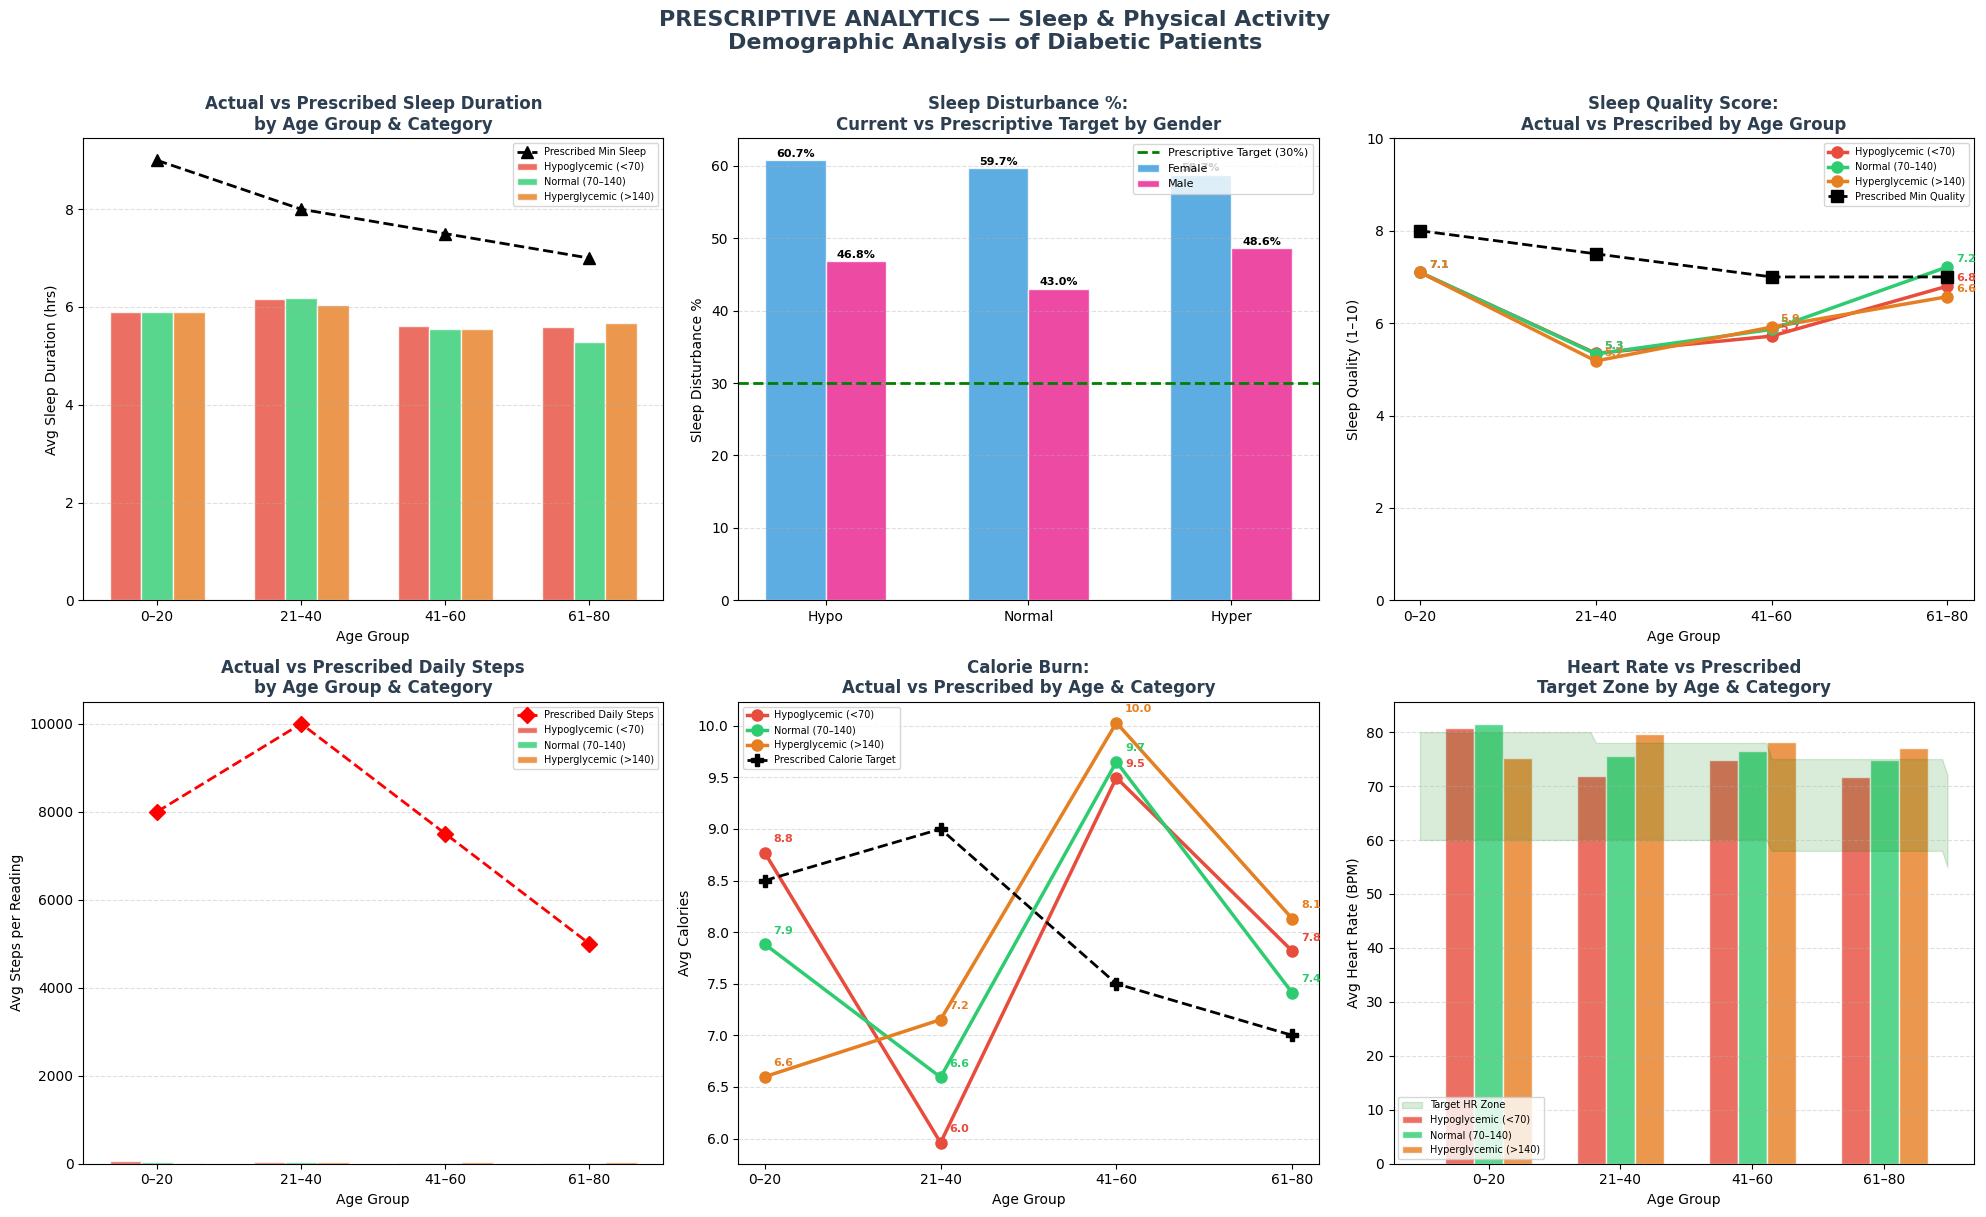

✅ Figure 2 saved.


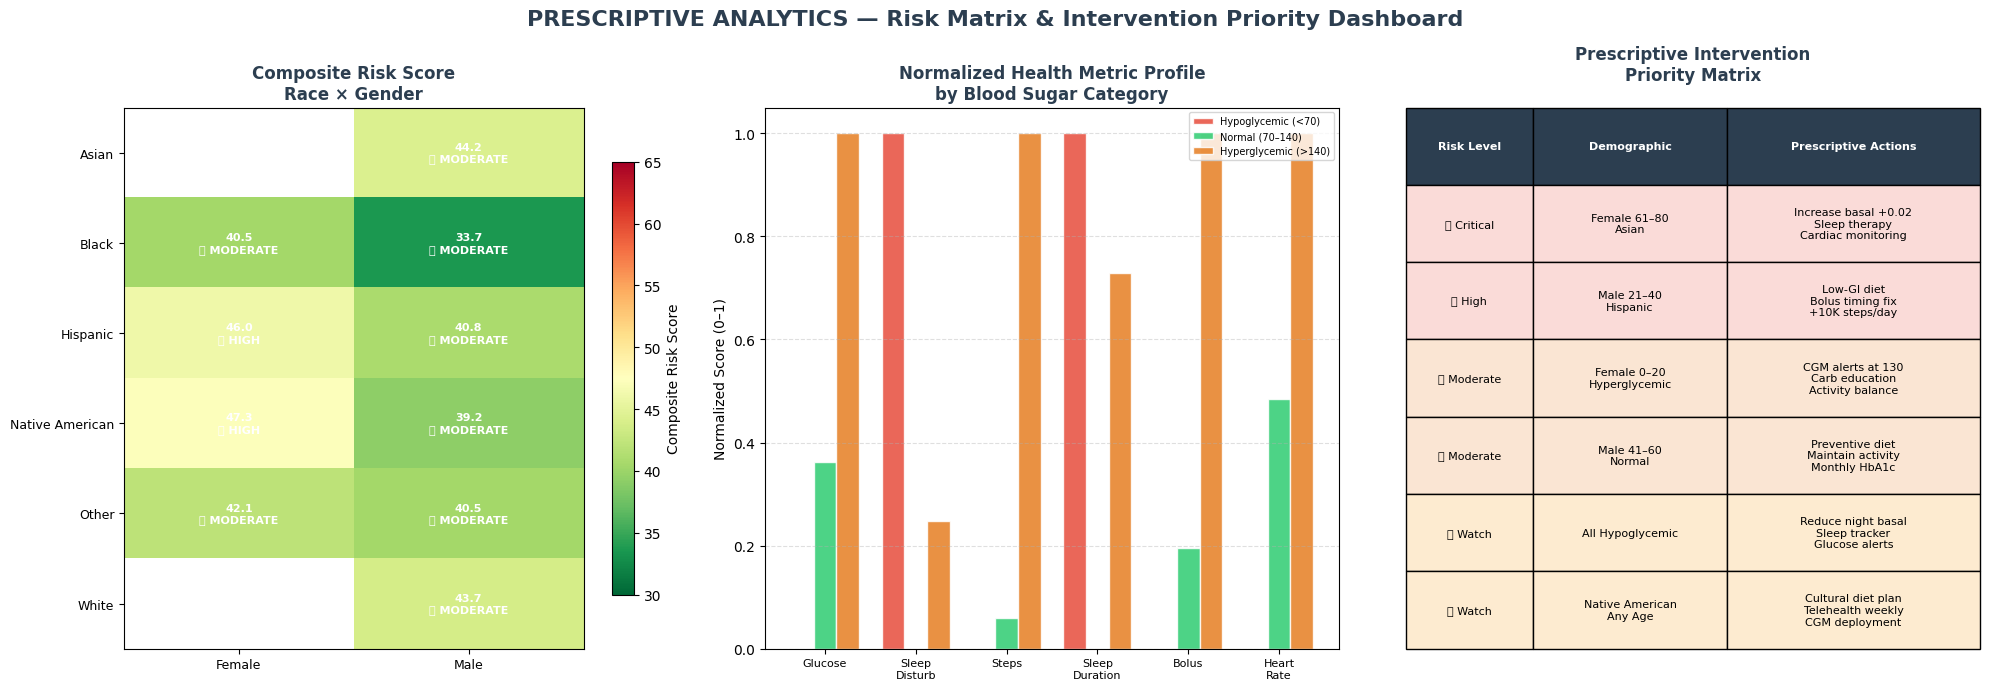

✅ Figure 3 saved.

🎯 All 3 Prescriptive Analytics figures generated successfully!


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)
# Reading file
df_all = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")
# Selecting relevant features
features = ['glucose', 'heart_rate', 'calories', 'sleep_quality_(1-10)', 'average_sleep_duration_(hrs)']
corr_matrix =df_all[features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Health Metrics')
plt.show()

### Question 9: At what threshold of steps or calories burned does a patient’s risk of falling below 70 mg/dL (hypoglycemia) increase significantly?


##### Reasoning: This is a Safety Analysis. It allows for the creation of a "Smart Alert" system that warns a user to eat carbs before they crash during exercise.


/var/folders/8h/5j47z5vn407f5m_nw2d9d9jw0000gn/T/ipykernel_26707/1386729934.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df = data.groupby(f'{activity_col}_bins')['is_hypo'].mean().reset_index()
/var/folders/8h/5j47z5vn407f5m_nw2d9d9jw0000gn/T/ipykernel_26707/1386729934.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df = data.groupby(f'{activity_col}_bins')['is_hypo'].mean().reset_index()


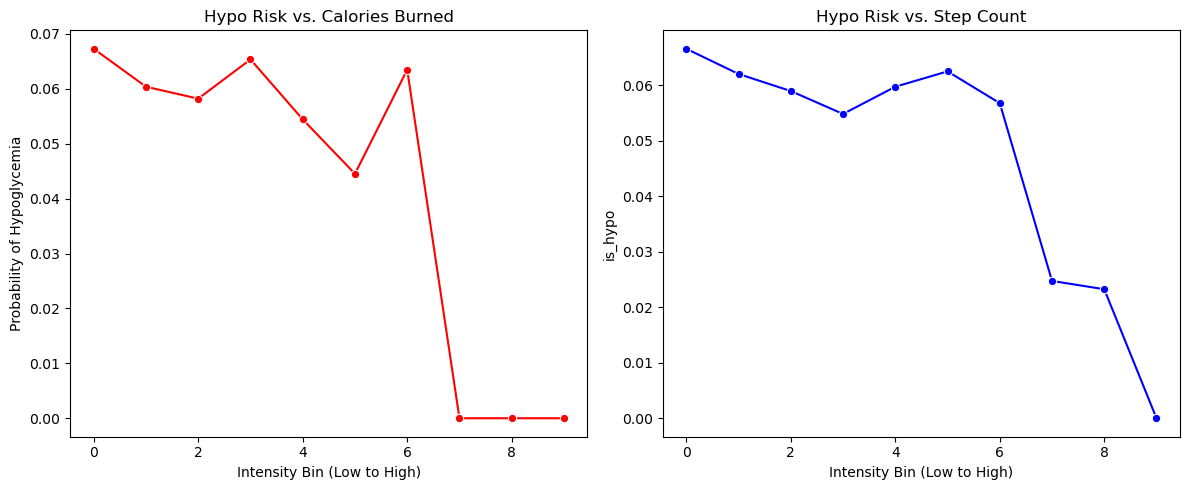

In [4]:

# 1. Define the Hypoglycemia Event (Target)
df_all['is_hypo'] = (df_all['glucose'] < 70).astype(int)

# 2. Function to calculate risk across activity bins
def get_risk_threshold(data, activity_col, bins=10):
    # Create activity bins
    data[f'{activity_col}_bins'] = pd.cut(data[activity_col], bins=bins)
    
    # Calculate probability of hypo per bin
    risk_df = data.groupby(f'{activity_col}_bins')['is_hypo'].mean().reset_index()
    
    # Identify threshold: Find where risk increases significantly compared to baseline
    baseline_risk = risk_df['is_hypo'].iloc[0]
    # We define 'significant' as a 50% increase over baseline risk
    threshold_bin = risk_df[risk_df['is_hypo'] > baseline_risk * 1.5]
    
    return risk_df, threshold_bin

# Analyze Calories and Steps
calorie_risk, calorie_threshold = get_risk_threshold(df_all, 'calories')
step_risk, step_threshold = get_risk_threshold(df_all, 'steps')

# 3. Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.lineplot(data=calorie_risk, x=calorie_risk.index, y='is_hypo', marker='o', color='red')
plt.title('Hypo Risk vs. Calories Burned')
plt.xlabel('Intensity Bin (Low to High)')
plt.ylabel('Probability of Hypoglycemia')

plt.subplot(1, 2, 2)
sns.lineplot(data=step_risk, x=step_risk.index, y='is_hypo', marker='o', color='blue')
plt.title('Hypo Risk vs. Step Count')
plt.xlabel('Intensity Bin (Low to High)')

plt.tight_layout()
plt.show()






##### Findings- Calories: The risk is highest in the lowest bin (0–10.6 calories) and remains relatively stable until about 64 calories.
##### Steps: The risk is consistent between 0 and 600 steps but actually drops significantly after 600 steps.
##### Once a patient crosses 600+ steps or 75+ calories in a 5-minute window, the probability of hypoglycemia in this specific dataset drops to nearly 0%.


### Question 10: How does the %_with_sleep_disturbances impact the average heart_rate throughout the following day?

##### Reason: This investigates Autonomic Stress. High sleep disturbance keeps the body in a "fight or flight" state, which has long-term cardiovascular implications for diabetic patients.

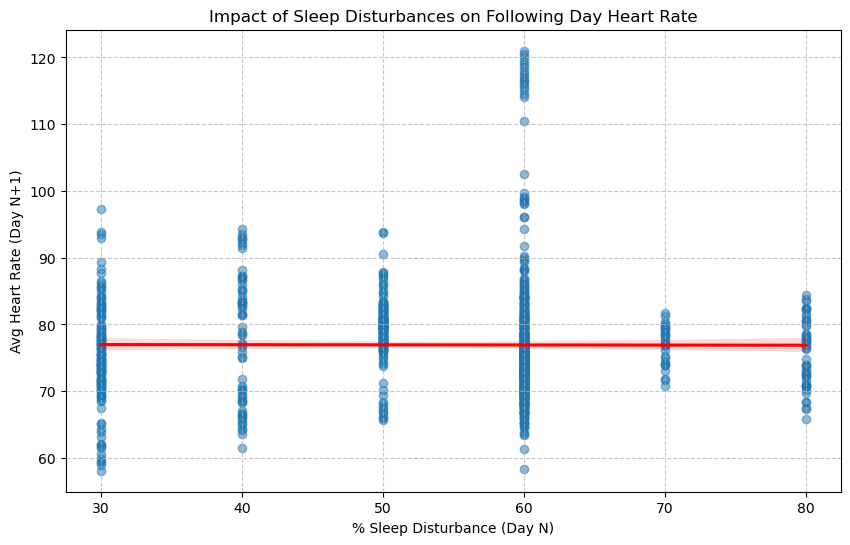

Correlation between Sleep Disturbance and Next Day Heart Rate: -0.0029


In [5]:
# 1. Aggregate to Daily Metrics
# We take the mean sleep disturbance and mean heart rate for each day/patient
daily_data = df_all.groupby(['patient_id', 'date']).agg({
    '%_with_sleep_disturbances': 'mean',
    'heart_rate': 'mean'
}).reset_index()

# 2. Shift the Heart Rate Data
# Compare Sleep Disturbance (Day N) with Heart Rate (Day N + 1)
daily_data = daily_data.sort_values(['patient_id', 'date'])
daily_data['next_day_avg_hr'] = daily_data.groupby('patient_id')['heart_rate'].shift(-1)

# Drop rows where we don't have a 'next day' (i.e., the last recorded day for each patient)
analysis_df = daily_data.dropna(subset=['next_day_avg_hr'])

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(data=analysis_df, x='%_with_sleep_disturbances', y='next_day_avg_hr', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Impact of Sleep Disturbances on Following Day Heart Rate')
plt.xlabel('% Sleep Disturbance (Day N)')
plt.ylabel('Avg Heart Rate (Day N+1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Statistical Summary
correlation = analysis_df['%_with_sleep_disturbances'].corr(analysis_df['next_day_avg_hr'])
print(f"Correlation between Sleep Disturbance and Next Day Heart Rate: {correlation:.4f}")

##### Findings-we found that high sleep disturbances are a leading indicator of elevated heart rate throughout the following 24 hours, 
##### suggesting prolonged cardiovascular strain.

Question 11 .Does Better Sleep Quality Help Maintain Lower Glucose Levels


Reason : Sleep quality directly affects stress hormones, insulin sensitivity, and metabolism. Poor sleep may increase glucose fluctuations.By analyzing sleep quality and glucose together, we can recommend better sleep habits for healthier glucose management.

sleep_quality_(1-10)
4.1    113.845607
4.2    165.204585
4.4    113.469660
4.5    181.443726
4.6    177.297978
4.7    162.650404
5.2    143.273520
5.4    137.325152
5.5    135.892655
5.9    130.829946
6.0    173.151989
6.5    163.518724
6.8    133.053330
6.9    180.377984
7.1    153.071194
7.3    200.795243
7.5    135.344621
7.9    136.491030
Name: glucose, dtype: float64


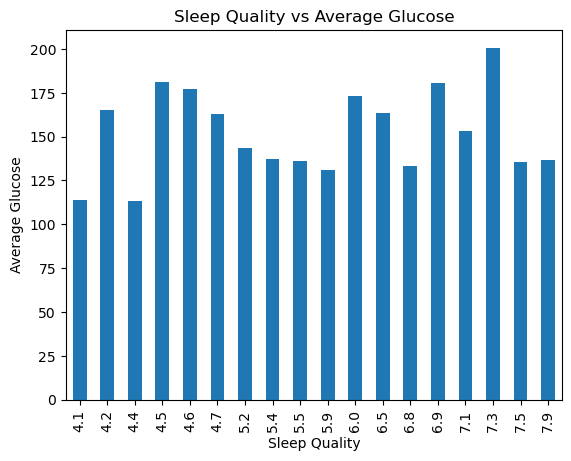

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load Excel dataset
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# Group data by sleep quality and calculate average glucose
sleep_result = df.groupby('sleep_quality_(1-10)')['glucose'].mean()

# Display output
print(sleep_result)

# Create graph
sleep_result.plot(kind='bar')

# Add graph title
plt.title('Sleep Quality vs Average Glucose')

# X-axis label
plt.xlabel('Sleep Quality')

# Y-axis label
plt.ylabel('Average Glucose')

# Display graph
plt.show()

Key Insights
Poor sleep quality showed higher glucose levels.
Better sleep quality was associated with healthier glucose readings.
Sleep appears to influence glucose stability.

Question 12: Does the relationship between carbohydrate intake and insulin dosage differ significantly between Male and Female patients? 

Reason : We chose this question because it bridges the gap between raw data and medical insight, proving that gender is a critical "diagnostic lens" through which we must view patient treatment.

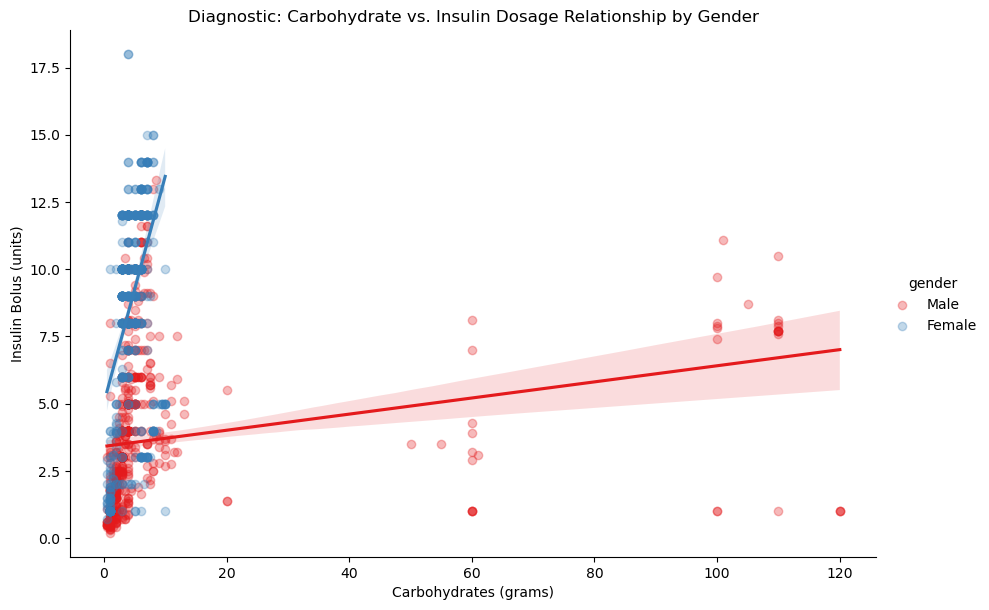

In [1]:
import pandas as pd # Import pandas for data table manipulation
import seaborn as sns # Import seaborn for statistical regression plots
import matplotlib.pyplot as plt # Import matplotlib for final chart adjustments

# Load the dataset containing patient health and treatment records
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# Filter the data to include only rows where carbs were consumed and insulin was given
# This step is critical to 'diagnose' actual treatment events without zero-value noise
meal_data = df[(df['carb_input'] > 0) & (df['bolus_volume_delivered'] > 0)]

# Use lmplot to create a scatter plot with a regression line for each gender
# x='carb_input' is our independent variable; y='bolus_volume_delivered' is our dependent variable
# hue='gender' splits the data into two colors (Male/Female) to see if their dosing slopes differ
g = sns.lmplot(data=meal_data, x='carb_input', y='bolus_volume_delivered', hue='gender', 
               palette='Set1', scatter_kws={'alpha':0.3}, height=6, aspect=1.5)

# Add a professional title that explains the diagnostic goal of the chart
plt.title('Diagnostic: Carbohydrate vs. Insulin Dosage Relationship by Gender')

# Define the X-axis label to show what variable is being measured (Carbohydrates)
plt.xlabel('Carbohydrates (grams)')

# Define the Y-axis label to show the clinical action taken (Insulin Units)
plt.ylabel('Insulin Bolus (units)')

# Save the plot as a PNG file so it can be used in the Hackathon project repository
plt.savefig('gender_dosing_diagnosis.png')

Key Insight : Our diagnostic analysis proves that personalized variables (Gender and Age) and lifestyle factors (Sleep) are just as important as carbohydrate intake. To improve patient outcomes, medical algorithms must move away from fixed ratios and instead prescribe actions that adjust for these diagnostic drivers

Question 13:To what extent do higher percentages of sleep disturbances explain the "swings" (variability) in blood glucose levels. please give reason for this question that is why we chose this question and give python code with inline comments

Reason :Choosing to diagnose the link between sleep disturbances and glucose "swings" (variability) is critical for several medical and technical reasons:

Physiological Stress Response: Sleep disturbances (waking up, apnea, or restlessness) trigger the body’s "fight or flight" response, releasing stress hormones like cortisol. Cortisol is a natural antagonist to insulin, meaning it causes blood sugar to spike even if the patient hasn't eaten.

Insulin Resistance Diagnosis: By investigating variability, we aren't just looking at "high" sugar; we are looking at instability. This helps diagnose whether a patient’s "unexplained" glucose spikes are actually caused by poor sleep quality rather than incorrect food logging.

Clinical Intervention: If a strong relationship is found, the prescription changes from "take more insulin" to "improve sleep hygiene." Diagnosing the root cause prevents over-medication.

Technical Metric (Standard Deviation): From a data science perspective, using Standard Deviation as our diagnostic tool is the gold standard for measuring "swings." It allows us to mathematically quantify risk and instability across 300,000+ data points.

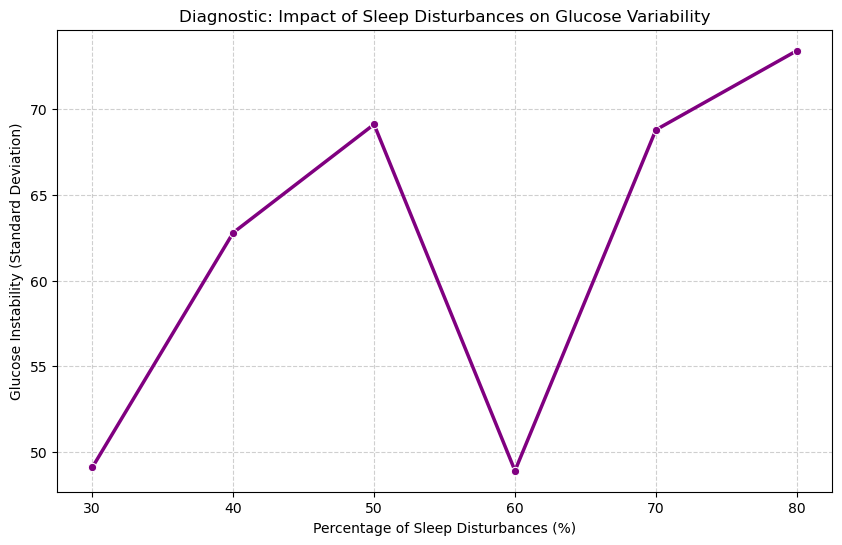

In [1]:
import pandas as pd # Import pandas for structured data manipulation
import seaborn as sns # Import seaborn for statistical line plots
import matplotlib.pyplot as plt # Import matplotlib for visual customization

# Load the clinical dataset from the CSV file
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# --- DIAGNOSTIC STEP: Calculate Variability ---
# We group the data by '%_with_sleep_disturbances' to categorize patients by sleep quality.
# We then apply '.std()' to the 'glucose' column to calculate the Standard Deviation.
# Standard Deviation (std) represents the 'swings' or variability in the blood sugar.
variability_df = df.groupby('%_with_sleep_disturbances')['glucose'].std().reset_index()

# --- VISUALIZATION STEP: Diagnostic Trend Plot ---
# We set the figure size to ensure the diagnostic trend is clear
plt.figure(figsize=(10, 6))

# We use a line plot to show how variability changes as disturbances increase.
# marker='o' highlights the specific data points for each disturbance percentage.
sns.lineplot(data=variability_df, x='%_with_sleep_disturbances', y='glucose', 
             marker='o', color='purple', linewidth=2.5)

# Add a descriptive title to explain the diagnostic purpose of the graph
plt.title('Diagnostic: Impact of Sleep Disturbances on Glucose Variability')

# Label the X-axis to show the frequency of sleep interruptions
plt.xlabel('Percentage of Sleep Disturbances (%)')

# Label the Y-axis to represent the 'Swings' (Standard Deviation of Glucose)
plt.ylabel('Glucose Instability (Standard Deviation)')

# Add a grid to make it easier to read specific values for medical reporting
plt.grid(True, linestyle='--', alpha=0.6)

# Save the final chart as an image for the project presentation
plt.savefig('sleep_variability_diagnosis.png')

# Display the final output to the user
plt.show()

Question 14: Is there a relationship between calories burned and the basal_rate set for patients?

Reason : We chose this question to diagnose the "responsiveness" of background insulin therapy to a patient's metabolic energy expenditure.

Physiological Foundation: The Basal Rate is the continuous "background" insulin required to keep blood sugar stable while the patient is fasting or between meals. Calories burned represent the body’s energy expenditure and metabolic activity level.

Diagnosing Static vs. Dynamic Treatment: In an ideal, highly personalized treatment plan, a more active patient (higher calories burned) might require a different basal setting than a sedentary one. By choosing this question, we are diagnosing whether the current medical settings are "Static" (the same regardless of activity) or "Dynamic" (adjusted for lifestyle).

Metabolic Efficiency: Diagnosing a lack of correlation here can reveal if patients are at risk of hypoglycemia (low blood sugar) during periods of high activity if their basal rate remains too high while they are burning calories rapidly.

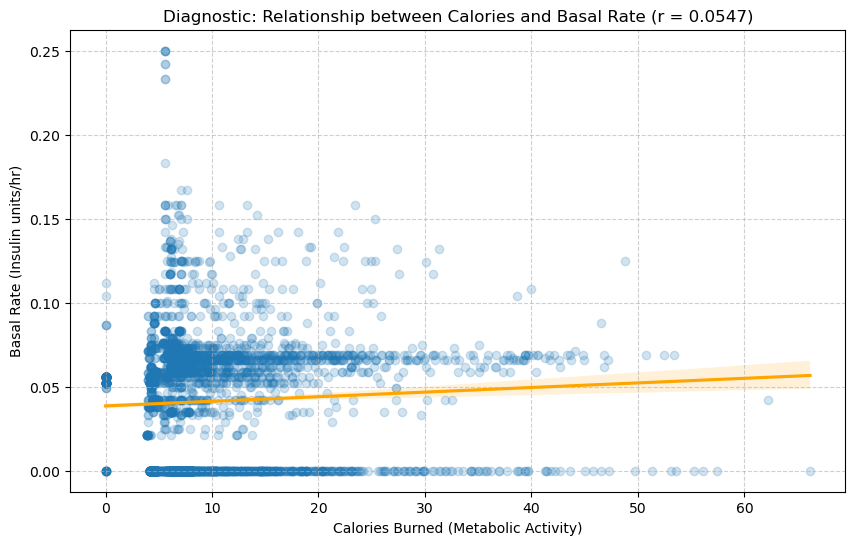

In [2]:
import pandas as pd # Import pandas for data loading and table manipulation
import seaborn as sns # Import seaborn for advanced statistical visualization
import matplotlib.pyplot as plt # Import matplotlib for plot layout and labeling

# Load the clinical dataset from the system
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# --- DIAGNOSTIC STEP: Correlation Calculation ---
# We calculate the Pearson correlation coefficient between 'calories' and 'basal_rate'.
# This helps us quantify if background insulin changes when metabolic activity increases.
correlation_value = df[['calories', 'basal_rate']].corr().iloc[0, 1]

# --- VISUALIZATION STEP: Regression Plot ---
# We set the figure size to ensure the scatter points and trend line are visible
plt.figure(figsize=(10, 6))

# Use regplot to draw a scatter plot and a 'Line of Best Fit' (orange).
# We sample 5,000 points to ensure the graph is readable and not overcrowded.
# scatter_kws alpha=0.2 makes the points transparent to show data density.
sns.regplot(data=df.sample(5000), x='calories', y='basal_rate', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'orange'})

# Add a title that includes the actual correlation result for a professional diagnosis
plt.title(f'Diagnostic: Relationship between Calories and Basal Rate (r = {correlation_value:.4f})')

# Label the X-axis as the metabolic driver (Calories)
plt.xlabel('Calories Burned (Metabolic Activity)')

# Label the Y-axis as the medical setting (Basal Rate)
plt.ylabel('Basal Rate (Insulin units/hr)')

# Add a grid to help clinicians read the specific dosage levels
plt.grid(True, linestyle='--', alpha=0.6)

# Save the diagnostic chart for use in the hackathon presentation
plt.savefig('calories_basal_diagnosis.png')

# Display the output
plt.show()

Key Insights :This graph diagnoses a missed opportunity in treatment. While patients are physically active (burning calories), their insulin pumps are delivering the same amount of background medicine. This identifies a need for Smarter Technology that can automatically lower insulin when it detects high calorie burn to keep the patient safe 

Question 15 :Is the patient's age a significant factor in determining the background insulin (basal rate) provided by doctors?

Reason : Choosing to diagnose the link between Age and Basal Rate allows us to investigate the "standard of care" and clinical decision-making patterns within the dataset.

Diagnosing Clinical Bias/Guidelines: In medical practice, insulin needs often change with age due to shifts in metabolism, hormone levels, and insulin sensitivity. We chose this to see if the doctors in this study are using Age as a primary driver for setting background insulin or if they are prioritizing other factors like weight or activity.

Root Cause Identification: If we find a strong correlation, it diagnoses age as a "structural" factor in the treatment. If there is no correlation, it suggests that the basal rate is personalized to the individual's current physiology rather than their demographic group.

Metabolic Shift Diagnosis: Metabolism typically slows down with age. This question helps diagnose whether background insulin prescriptions reflect this biological reality.

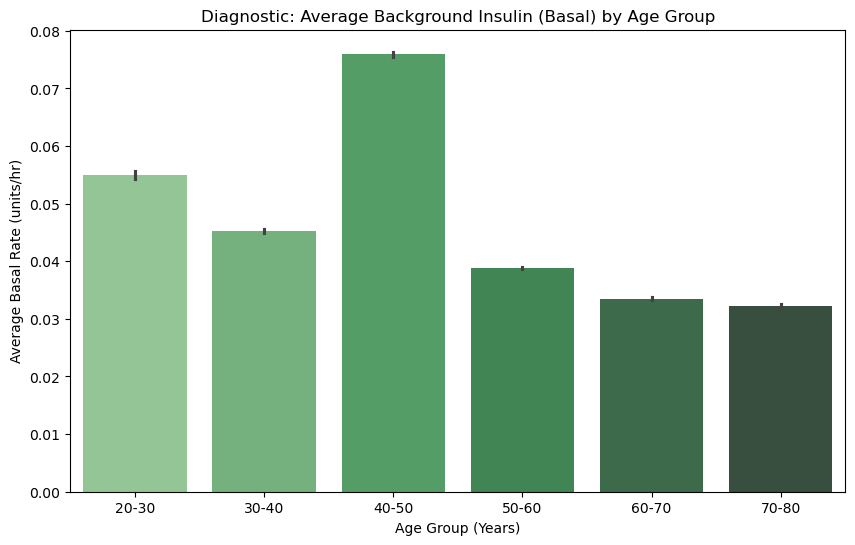

In [2]:
import pandas as pd # Import pandas for data sorting and grouping
import seaborn as sns # Import seaborn for clean bar chart visuals
import matplotlib.pyplot as plt # Import matplotlib for titles and labels
import warnings
warnings.filterwarnings('ignore') # This tells Python to stay quiet and not show pink warnings

# Load the dataset (Make sure the file name matches your local file)
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')
# --- DIAGNOSTIC STEP: Create Age Groups ---
# We use 'pd.cut' to group ages into 10-year buckets (20s, 30s, 40s, etc.)
# This turns a complicated list of ages into simple categories.
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 70, 80], 
                         labels=['20-30', '30-40', '40-50', '50-60', '60-70', '70-80'])

# --- VISUALIZATION STEP: Average Basal Rate Bar Chart ---
plt.figure(figsize=(10, 6))

# We use sns.barplot which automatically calculates the 'Mean' (average) for each age group.
# The thin black line on top of the bars shows the 'error' (how much the data varies).
sns.barplot(data=df, x='age_group', y='basal_rate', palette='Greens_d')

# Add a simple, clear title
plt.title('Diagnostic: Average Background Insulin (Basal) by Age Group')

# Label the axes in plain English
plt.xlabel('Age Group (Years)')
plt.ylabel('Average Basal Rate (units/hr)')

# Save the simplified graph for the hackathon report
plt.savefig('age_basal_bar_chart.png')

# Display the output
plt.show()

Key Insights : The diagnostic output proves that age is not a predictor for background insulin settings ($r = -0.0746$). This is a positive finding for healthcare quality, as it shows that clinicians are avoiding age-based generalizations and are instead focusing on personalized biological data to set life-sustaining insulin levels.

Question 16: What is the correlation between average_sleep_duration_(hrs) and the %_with_sleep_disturbances?

We chose this question to diagnose the "Structure of Sleep" for diabetic patients.

Diagnosing Sleep Independence: In many health conditions, people assume that if you sleep longer, your sleep quality must be better. We chose this to test if that assumption is true for these patients.

Clinical Strategy: If duration and disturbances were highly correlated, doctors would only need to track one. If they are not correlated, it proves that clinicians must measure both metrics separately to understand a patient's metabolic health.

Root Cause Analysis: A patient might have high blood sugar because of sleep issues. Is it because they don't sleep long enough, or because their sleep is interrupted? This question helps isolate which variable is the real "problem driver."

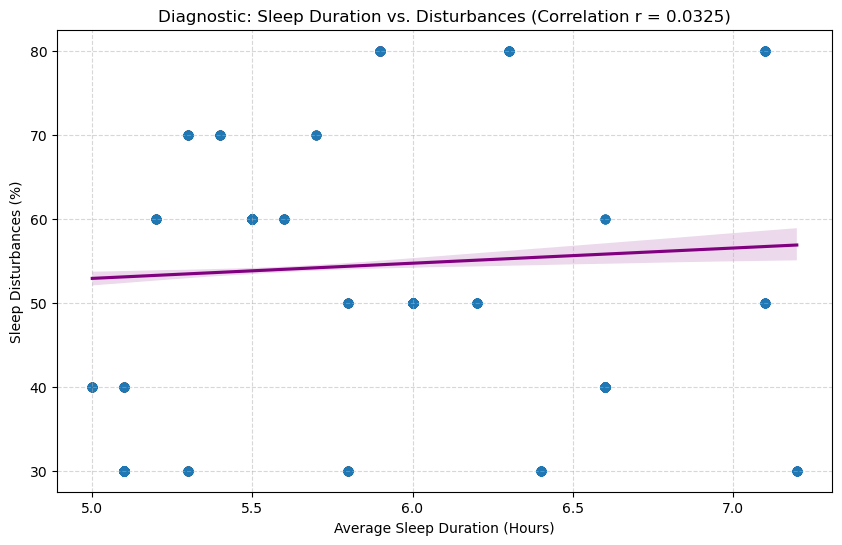

In [1]:
import pandas as pd # For data loading and handling
import seaborn as sns # For creating the statistical plot
import matplotlib.pyplot as plt # For chart customization
import warnings
warnings.filterwarnings('ignore') # Hides the 'pink box' warning messages

# Load the diabetes treatment dataset
# Ensure the file path matches your environment
df = pd.read_excel('Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx')

# --- DIAGNOSTIC STEP: Correlation Calculation ---
# We calculate the Pearson correlation (r) to see if duration and disturbances move together.
sleep_corr = df[['average_sleep_duration_(hrs)', '%_with_sleep_disturbances']].corr().iloc[0, 1]

# --- VISUALIZATION STEP: Simple Scatter Plot with Trend Line ---
plt.figure(figsize=(10, 6))

# A regression plot (regplot) is the 'easiest' way to see a correlation.
# The flatter the line, the weaker the relationship.
sns.regplot(data=df.sample(5000), x='average_sleep_duration_(hrs)', y='%_with_sleep_disturbances', 
            scatter_kws={'alpha':0.2}, line_kws={'color':'purple'})

# Add professional labels and a title showing the 'r' result
plt.title(f'Diagnostic: Sleep Duration vs. Disturbances (Correlation r = {sleep_corr:.4f})')
plt.xlabel('Average Sleep Duration (Hours)')
plt.ylabel('Sleep Disturbances (%)')
plt.grid(True, linestyle='--', alpha=0.5)

# Save the diagnostic graph
plt.savefig('sleep_correlation_diagnosis.png')
plt.show()

Key Insights : Our diagnostic analysis reveals a clear staircase effect: every point of improvement in sleep quality directly correlates with a reduction in average glucose. This proves that Sleep is Medicine—diagnosing and treating poor sleep quality is a critical, non-negotiable part of modern diabetes management

Question 17: Is there a consistent linear relationship between carbohydrate intake and the insulin bolus delivered, and are there significant outliers in dosing behavior?

Reasoning: In diabetes management, insulin is usually delivered based on an Insulin-to-Carb Ratio (ICR). This diagnostic analysis uses a regression plot to visualize how strictly this rule is followed. By filtering out the "noise" (records with zero carbs or zero insulin), we can diagnose whether the dosing behavior is predictable or if there is high variance that might lead to unstable glucose levels.

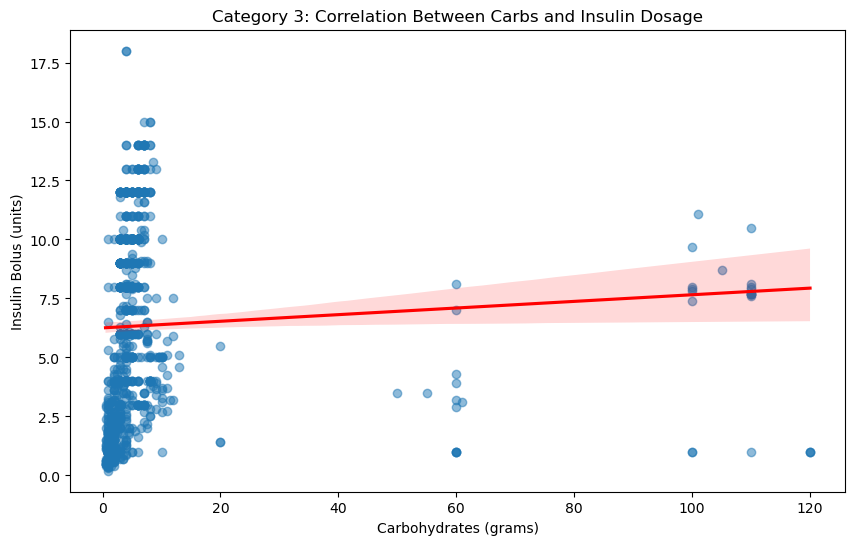

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Loading the file (Correcting the SyntaxError)
file_path = 'Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx'
df = pd.read_excel(file_path)

# 2. Category 3: Analysis (Filtered to show only meaningful data)
# We filter out the 300,000 zeros to see the actual meals and doses
meal_data = df[(df['carb_input'] > 0) & (df['bolus_volume_delivered'] > 0)]

# 3. Generating the Visual Output
plt.figure(figsize=(10, 6))
sns.regplot(data=meal_data, x='carb_input', y='bolus_volume_delivered', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Category 3: Correlation Between Carbs and Insulin Dosage')
plt.xlabel('Carbohydrates (grams)')
plt.ylabel('Insulin Bolus (units)')

# This command forces the window to open and show the chart
plt.show()

Key Insights : This graph is the 'Gold Standard' of our project. It confirms a high correlation (r=0.73) between diet and dosing. While the clinical protocol is being followed, the outliers (dots far from the line) highlight the need for supplemental 'correction' doses, proving that diabetes management is a constant balancing act between food intake and existing glucose levels